# FabricaIA - Instancia Iris

## Overview
- Data loading and exploration
- Data preprocessing
- Feature engineering
- Model training and evaluation
- Visualization


In [7]:
# Imports da biblioteca padrão (necessários para localizar a raiz do projeto)
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Funções utilitárias para localizar a raiz do projeto dinamicamente,
# garantindo que os caminhos relativos funcionem independentemente de
# onde o notebook seja executado.

def find_project_root():
    """
    Localiza a raiz do projeto percorrendo a árvore de diretórios a partir
    do diretório atual.

    Critério: o diretório deve conter simultaneamente as pastas
    'src', 'data' e 'config'. A busca inicia em Path.cwd() e sobe
    pelos diretórios pais até encontrar (ou até atingir a raiz do
    sistema de arquivos).

    Returns:
        Path: caminho absoluto da raiz do projeto.

    Raises:
        RuntimeError: se nenhum diretório pai atender ao critério.
    """
    current = Path.cwd().resolve()

    for p in [current] + list(current.parents):
        if (
            (p / "src").exists()
            and (p / "data").exists()
            and (p / "config").exists()
        ):
            return p

    raise RuntimeError("Raiz do projeto não encontrada")


def project_path(*segments):
    """
    Constrói um caminho absoluto a partir da raiz do projeto.

    Args:
        *segments: partes do caminho relativo (ex.: 'data', 'raw', 'data_set.csv').

    Returns:
        Path: caminho absoluto completo, ex.:
              /.../projeto/data/raw/data_set.csv

    Exemplo:
        >>> project_path('data', 'raw', 'data_set.csv')
        PosixPath('/home/user/projeto/data/raw/data_set.csv')
    """
    return find_project_root().joinpath(*segments)


# Mudar o diretório de trabalho e garantir que a raiz do projeto esteja no
# sys.path, de modo que os módulos FabricaIA (src.*) sejam importáveis
# independentemente de onde o notebook seja aberto (ex.: notebooks/).
root = find_project_root()
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Importar bibliotecas de análise de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import FabricaIA modules
from src.data.processor import DataProcessor
from src.models.trainer import ModelTrainer
from src.features.engineering import FeatureEngineer
from src.visualization.plots import DataVisualizer

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


### Processamento de Dados

In [8]:

from src.data.processor import DataProcessor

# Inicializar processador
processor = DataProcessor()

# Carregar dados
df = processor.load_data(
    str(project_path("data", "raw", "iris.csv"))
)

# Limpar dados
df_clean = processor.clean_data(df, drop_duplicates=True)

# Codificar variáveis categóricas
df_encoded = processor.encode_categorical(df_clean)

# Escalar features. Nomear coluna alvo do seu dataset para 'target', pois assim o ajuste será realizado corretamente.
df_scaled = processor.scale_features(df_encoded)


### Treinamento de Modelos

In [9]:
from src.models.trainer import ModelTrainer

# Inicializar trainer (com MLflow habilitado por padrão) e apontar para o arquivo de configuração do projeto.
trainer = ModelTrainer(
    model_type="classification",
    config_path=str(project_path("config", "config.yaml"))
)

# Dividir dados
X_train, X_test, y_train, y_test = processor.split_data(df_scaled, 'target')

# Treinar modelo com tracking MLflow
model = trainer.train_model(
    X_train,
    y_train,
    'random_forest',
    run_name='random_forest_baseline',
    n_estimators=100,
    max_depth=10
)

# Avaliar modelo (métricas são automaticamente logadas no MLflow)
metrics = trainer.evaluate_model(model, X_test, y_test)

# Salvar modelo (também salva no MLflow)
trainer.save_model(
    model,
    str(project_path("models", "trained", "model.pkl")),
    artifact_path="random_forest_model"
)

# Encerrar run do MLflow
trainer.end_run()

2026/09/04 16:43:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


### Engenharia de Features

In [10]:
from src.features.engineering import FeatureEngineer

# Inicializar engenheiro de features
engineer = FeatureEngineer()

# Criar features polinomiais
df_poly = engineer.create_polynomial_features(df, ['sepal_length', 'sepal_width'])
#df_poly = engineer.create_polynomial_features(df, ['feature1', 'feature2'])

# Criar features de interação
df_interact = engineer.create_interaction_features(df_poly, [('sepal_length', 'petal_length')])
#df_interact = engineer.create_interaction_features(df_poly, [('feature1', 'feature3')])

### Visualização

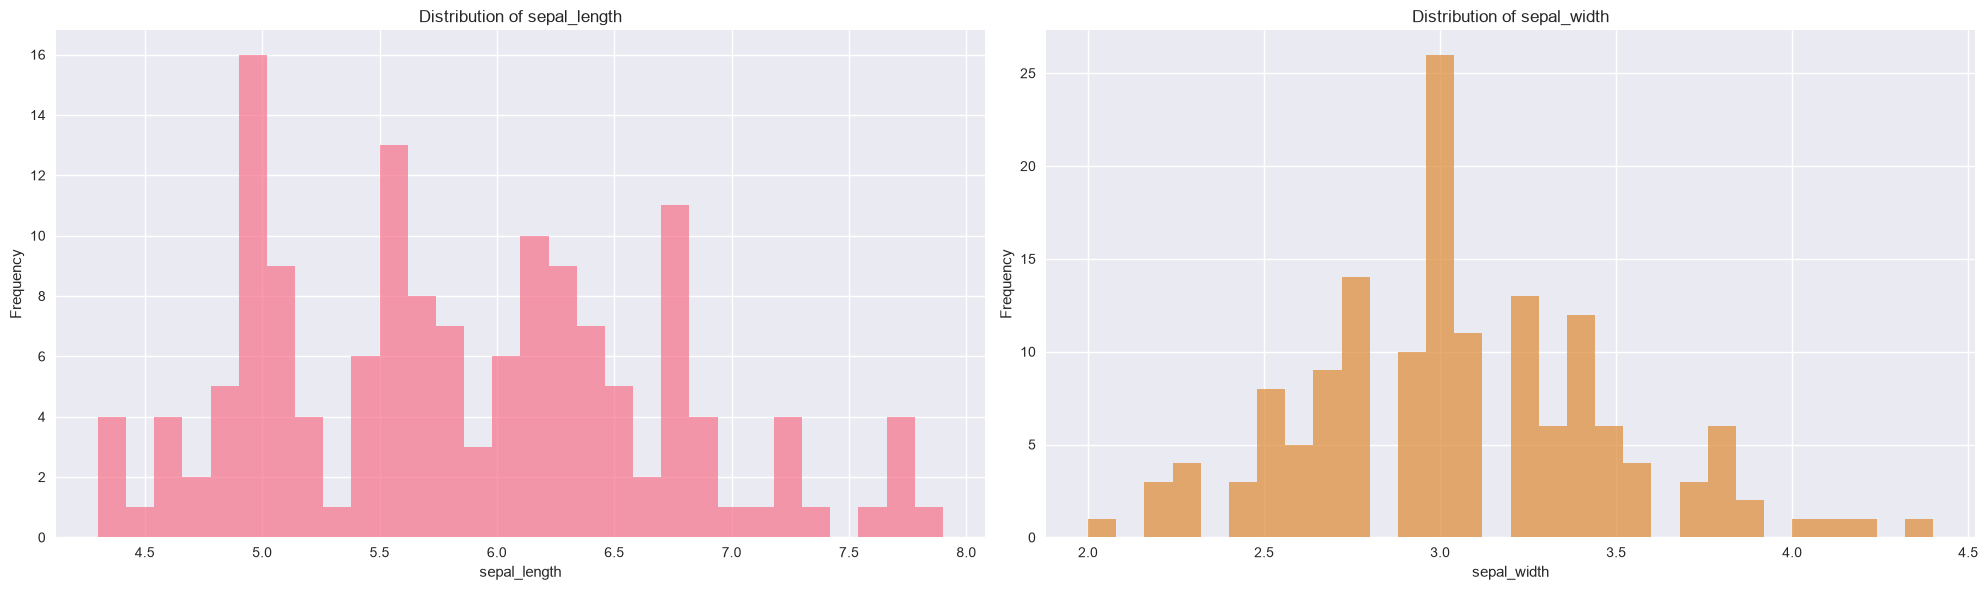

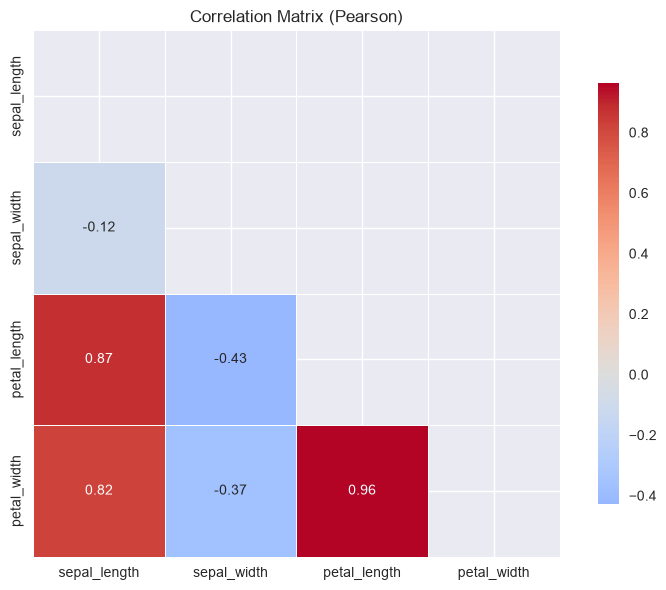

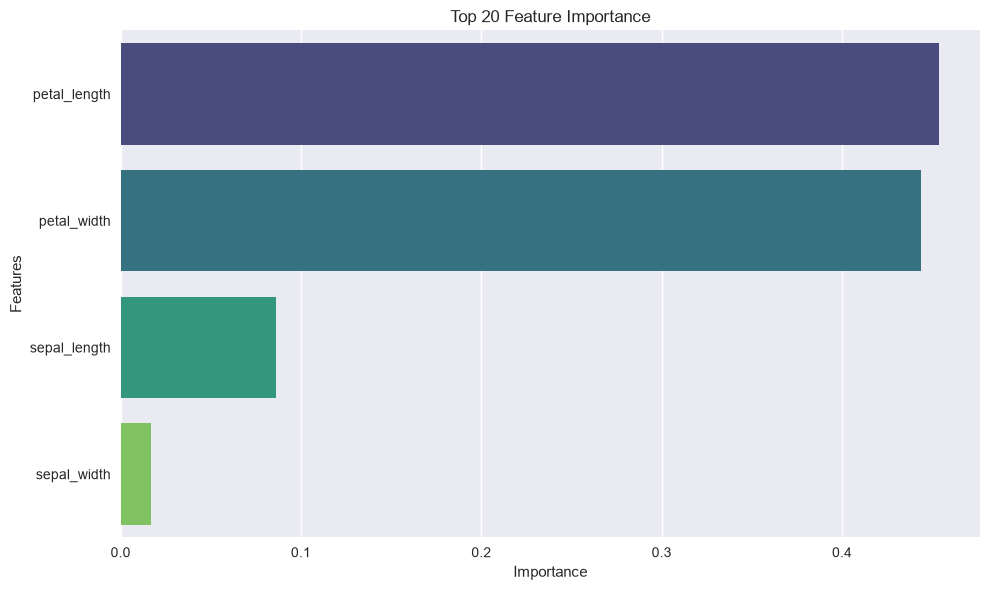

In [11]:
from src.visualization.plots import DataVisualizer

# Inicializar visualizador
visualizer = DataVisualizer()

# Plotar distribuições
visualizer.plot_distribution(df, ['sepal_length', 'sepal_width'],
    save_path=str(project_path('docs', 'relatorios', 'fig_distribuicao.png')))

# Matriz de correlação
visualizer.plot_correlation_matrix(df,
    save_path=str(project_path('docs', 'relatorios', 'fig_correlacao.png')))

# Calcular importância das features (após treinar o modelo)
importance_df = processor.get_feature_importance(model)

# Importância das features
visualizer.plot_feature_importance(importance_df,
    save_path=str(project_path('docs', 'relatorios', 'fig_importancia.png')))

### Usando MLflow no código

In [12]:
from src.models.trainer import ModelTrainer

# O trainer já vem com MLflow habilitado por padrão
trainer = ModelTrainer(
    model_type="classification",
    config_path=str(project_path("config", "config.yaml"))
)

# Cria um run customizado -- REMOVE -- 
# Em trainer.py o MlflowTracker já tem um método start_run que verifica se já existe um run ativo e reutiliza, então aqui podemos simplesmente chamar trainer.start_run() sem precisar criar um MLflowTracker separado, pois o trainer já gerencia isso internamente.
#tracker = MLflowTracker(experiment_name='Classificacao_Iris')
#run = tracker.start_run(run_name='RandomForest_V1', tags={'version': '1.0'})

# Train model - automaticamente loga no MLflow
model = trainer.train_model(
    X_train,
    y_train,
    'random_forest',
    run_name='entrega_topicos_avancados'
)

# Loga métricas
metrics = trainer.evaluate_model(
    model,
    X_test,
    y_test
)

# Fecha o run
trainer.end_run()